In [1]:
import os
from dataclasses import dataclass
from typing import Dict, List, Tuple, Optional, Any

import numpy as np
import tensorflow as tf
import sys
sys.path.insert(0, "/home/mineuih/waymax_rs/waymo-open-dataset/src")
from waymo_open_dataset.protos import scenario_pb2
print("import success:", scenario_pb2.__file__)

# ---------------------S--------
# Data containers
# -----------------------------
@dataclass
class LaneNode:
    lane_feature_id: int
    point_index: int
    xyz: np.ndarray  # shape (3,)


@dataclass
class LaneGraph:
    scenario_id: str
    nodes_xyz: np.ndarray                  # [N, 3]
    node_lane_ids: np.ndarray             # [N]
    node_point_indices: np.ndarray        # [N]
    polyline_edges: np.ndarray            # [E1, 2]  (within-lane consecutive points)
    successor_edges: np.ndarray           # [E2, 2]  (last node of lane A -> first node of lane B)
    predecessor_edges: np.ndarray         # [E3, 2]
    left_neighbor_edges: np.ndarray       # [E4, 2]  (optional, lane-level approximated as end->start)
    right_neighbor_edges: np.ndarray      # [E5, 2]
    lane_id_to_node_range: Dict[int, Tuple[int, int]]  # lane_id -> [start_node_idx, end_node_idx_exclusive]

I0000 00:00:1775512399.436251 3883540 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1775512399.480922 3883540 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1775512402.509220 3883540 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


import success: /home/mineuih/waymax_rs/waymo-open-dataset/src/waymo_open_dataset/protos/scenario_pb2.py


In [2]:
import matplotlib.pyplot as plt

# -----------------------------
# Helpers: robust tf.Example parsing
# -----------------------------
def _bytes_feature_to_str(feature: tf.train.Feature) -> str:
    if feature.bytes_list.value:
        return feature.bytes_list.value[0].decode("utf-8")
    raise KeyError("Feature is not a bytes feature or is empty.")


def _int64_feature_to_int(feature: tf.train.Feature) -> int:
    if feature.int64_list.value:
        return int(feature.int64_list.value[0])
    raise KeyError("Feature is not an int64 feature or is empty.")

def get_feature_array(feature):
    """tf.train.Feature -> numpy array"""
    if len(feature.float_list.value) > 0:
        return np.array(feature.float_list.value, dtype=np.float32)
    if len(feature.int64_list.value) > 0:
        return np.array(feature.int64_list.value, dtype=np.int64)
    if len(feature.bytes_list.value) > 0:
        return np.array(feature.bytes_list.value)
    return None


def extract_tfexample_roadgraph_points(ex):
    feats = ex.features.feature


    # 1) xyz 한 번에 저장된 경우
    key = "roadgraph_samples/xyz"
    if key in feats:
        arr = get_feature_array(feats[key])
        arr = np.asarray(arr, dtype=np.float32)
        valid = get_feature_array(feats.get("roadgraph_samples/valid"))

        if arr.size % 3 != 0:
            raise ValueError(f"{key} size={arr.size} is not divisible by 3")

        return arr.reshape(-1, 3)[valid.astype(bool)]
    available = sorted(feats.keys())
    raise KeyError(
        "Could not find tfexample roadgraph point keys. "
        f"Available keys include: {available[:100]}"
    )

def get_scenario_id_from_tfexample_bytes(example_bytes: bytes) -> str:
    """
    Try several likely feature names for scenario id.
    Different preprocessing pipelines may use different names.
    """
    ex = tf.train.Example()
    ex.ParseFromString(example_bytes)
    feats = ex.features.feature

    candidate_keys = [
        "scenario/id",
        "scenario_id",
        "state/scenario_id",
        "id",
    ]

    for key in candidate_keys:
        if key in feats:
            f = feats[key]
            # Usually bytes, sometimes int64/string-like
            if f.bytes_list.value:
                return _bytes_feature_to_str(f)
            if f.int64_list.value:
                return str(_int64_feature_to_int(f))

    available = list(feats.keys())[:50]
    raise KeyError(
        "Could not find scenario id in tf.Example. "
        f"Tried keys={candidate_keys}. "
        f"Available example keys (first 50)={available}"
    )


# -----------------------------
# Helpers: inspect map feature type
# -----------------------------
def get_map_feature_type_name(map_feature: Any) -> Optional[str]:
    """
    Returns the active oneof field name for Scenario.map_features item.
    Common values include: lane, road_line, road_edge, crosswalk, speed_bump, stop_sign, driveway
    depending on WOMD version.
    """
    # Newer protobuf API supports WhichOneof
    try:
        return map_feature.WhichOneof("feature_data")
    except Exception:
        pass

    # Fallback: heuristic
    candidate_fields = [
        "lane",
        "road_line",
        "road_edge",
        "crosswalk",
        "speed_bump",
        "stop_sign",
        "driveway",
    ]
    for name in candidate_fields:
        try:
            field = getattr(map_feature, name)
            # Heuristic: serialized size > 0 means present
            if field is not None and field.ByteSize() > 0:
                return name
        except Exception:
            continue
    return None


def polyline_to_xyz(polyline) -> np.ndarray:
    pts = np.array([[p.x, p.y, p.z] for p in polyline], dtype=np.float32)
    return pts


# -----------------------------
# Scenario -> lane graph
# -----------------------------
def build_lane_graph_from_scenario(
    scenario: scenario_pb2.Scenario,
    include_lane_relations: bool = True,
) -> LaneGraph:
    """
    Builds a point-level lane graph from Scenario.map_features.

    Node:
      each point in each lane center polyline

    Edges:
      - polyline_edges: consecutive points within a lane
      - successor_edges / predecessor_edges:
          if lane relation fields exist, connect lane end -> successor start
      - left/right_neighbor_edges:
          approximated lane-level relation edge using lane start nodes
          (because neighbor relation is lane-level, not point-level)
    """
    scenario_id = scenario.scenario_id

    nodes_xyz_list: List[np.ndarray] = []
    node_lane_ids_list: List[np.ndarray] = []
    node_point_indices_list: List[np.ndarray] = []
    polyline_edges: List[Tuple[int, int]] = []

    lane_id_to_node_range: Dict[int, Tuple[int, int]] = {}
    lane_feature_map: Dict[int, Any] = {}

    # 1) collect lane polylines
    global_node_offset = 0
    for mf in scenario.map_features:
        feature_type = get_map_feature_type_name(mf)
        if feature_type != "lane":
            continue

        lane = mf.lane
        lane_id = int(mf.id)
        lane_feature_map[lane_id] = lane

        pts = polyline_to_xyz(lane.polyline)
        if len(pts) == 0:
            continue

        n = len(pts)
        start = global_node_offset
        end = global_node_offset + n

        lane_id_to_node_range[lane_id] = (start, end)
        nodes_xyz_list.append(pts)
        node_lane_ids_list.append(np.full((n,), lane_id, dtype=np.int64))
        node_point_indices_list.append(np.arange(n, dtype=np.int64))

        for i in range(start, end - 1):
            polyline_edges.append((i, i + 1))

        global_node_offset = end

    if not nodes_xyz_list:
        return LaneGraph(
            scenario_id=scenario_id,
            nodes_xyz=np.zeros((0, 3), dtype=np.float32),
            node_lane_ids=np.zeros((0,), dtype=np.int64),
            node_point_indices=np.zeros((0,), dtype=np.int64),
            polyline_edges=np.zeros((0, 2), dtype=np.int64),
            successor_edges=np.zeros((0, 2), dtype=np.int64),
            predecessor_edges=np.zeros((0, 2), dtype=np.int64),
            left_neighbor_edges=np.zeros((0, 2), dtype=np.int64),
            right_neighbor_edges=np.zeros((0, 2), dtype=np.int64),
            lane_id_to_node_range={},
        )

    nodes_xyz = np.concatenate(nodes_xyz_list, axis=0)
    node_lane_ids = np.concatenate(node_lane_ids_list, axis=0)
    node_point_indices = np.concatenate(node_point_indices_list, axis=0)

    successor_edges: List[Tuple[int, int]] = []
    predecessor_edges: List[Tuple[int, int]] = []
    left_neighbor_edges: List[Tuple[int, int]] = []
    right_neighbor_edges: List[Tuple[int, int]] = []

    # 2) lane-to-lane relations if available in the proto
    if include_lane_relations:
        for lane_id, lane in lane_feature_map.items():
            src_range = lane_id_to_node_range.get(lane_id)
            if src_range is None:
                continue

            src_start, src_end = src_range
            src_first = src_start
            src_last = src_end - 1

            # successor lanes
            if hasattr(lane, "exit_lanes"):
                for succ_lane_id in lane.exit_lanes:
                    succ_lane_id = int(succ_lane_id)
                    dst_range = lane_id_to_node_range.get(succ_lane_id)
                    if dst_range is not None:
                        dst_first = dst_range[0]
                        successor_edges.append((src_last, dst_first))

            # predecessor lanes
            if hasattr(lane, "entry_lanes"):
                for pred_lane_id in lane.entry_lanes:
                    pred_lane_id = int(pred_lane_id)
                    pred_range = lane_id_to_node_range.get(pred_lane_id)
                    if pred_range is not None:
                        pred_last = pred_range[1] - 1
                        predecessor_edges.append((pred_last, src_first))

            # left neighbors
            # Depending on WOMD version, neighbor fields can differ.
            # We try a few common patterns.
            left_neighbor_lane_ids = []

            if hasattr(lane, "left_neighbors"):
                for nb in lane.left_neighbors:
                    if hasattr(nb, "feature_id"):
                        left_neighbor_lane_ids.append(int(nb.feature_id))
                    elif hasattr(nb, "lane_id"):
                        left_neighbor_lane_ids.append(int(nb.lane_id))

            for nb_lane_id in left_neighbor_lane_ids:
                dst_range = lane_id_to_node_range.get(nb_lane_id)
                if dst_range is not None:
                    # lane-level approximate relation edge
                    left_neighbor_edges.append((src_first, dst_range[0]))

            # right neighbors
            right_neighbor_lane_ids = []

            if hasattr(lane, "right_neighbors"):
                for nb in lane.right_neighbors:
                    if hasattr(nb, "feature_id"):
                        right_neighbor_lane_ids.append(int(nb.feature_id))
                    elif hasattr(nb, "lane_id"):
                        right_neighbor_lane_ids.append(int(nb.lane_id))

            for nb_lane_id in right_neighbor_lane_ids:
                dst_range = lane_id_to_node_range.get(nb_lane_id)
                if dst_range is not None:
                    right_neighbor_edges.append((src_first, dst_range[0]))

    return LaneGraph(
        scenario_id=scenario_id,
        nodes_xyz=nodes_xyz,
        node_lane_ids=node_lane_ids,
        node_point_indices=node_point_indices,
        polyline_edges=np.asarray(polyline_edges, dtype=np.int64).reshape(-1, 2),
        successor_edges=np.asarray(successor_edges, dtype=np.int64).reshape(-1, 2),
        predecessor_edges=np.asarray(predecessor_edges, dtype=np.int64).reshape(-1, 2),
        left_neighbor_edges=np.asarray(left_neighbor_edges, dtype=np.int64).reshape(-1, 2),
        right_neighbor_edges=np.asarray(right_neighbor_edges, dtype=np.int64).reshape(-1, 2),
        lane_id_to_node_range=lane_id_to_node_range,
    )


# -----------------------------
# Build index from original Scenario TFRecord
# -----------------------------
def build_scenario_lane_graph_index(
    scenario_tfrecord_paths: List[str],
    max_scenarios: Optional[int] = None,
    verbose: bool = True,
) -> Dict[str, LaneGraph]:
    """
    Reads original Scenario TFRecords and builds:
      scenario_id -> LaneGraph
    """
    graph_index: Dict[str, LaneGraph] = {}
    num = 0

    for path in scenario_tfrecord_paths:
        ds = tf.data.TFRecordDataset(path)
        for raw in ds:
            scenario = scenario_pb2.Scenario()
            scenario.ParseFromString(raw.numpy())

            graph = build_lane_graph_from_scenario(scenario)
            graph_index[graph.scenario_id] = graph

            num += 1
            if verbose and num % 100 == 0:
                print(f"[build_index] processed {num} scenarios")

            if max_scenarios is not None and num >= max_scenarios:
                return graph_index

    return graph_index


# -----------------------------
# Match tf.Example -> lane graph
# -----------------------------
# def iterate_tfexamples_with_lane_graph(
#     tfexample_paths: List[str],
#     lane_graph_index: Dict[str, LaneGraph],
#     max_examples: Optional[int] = None,
# ):
#     """
#     Yields:
#       scenario_id, tf.train.Example, LaneGraph
#     """
#     num = 0
#     for path in tfexample_paths:
#         ds = tf.data.TFRecordDataset(path)
#         for raw in ds:
#             ex_bytes = raw.numpy()
#             scenario_id = get_scenario_id_from_tfexample_bytes(ex_bytes)

#             if scenario_id not in lane_graph_index:
#                 # unmatched; skip or raise depending on your needs
#                 continue

#             ex = tf.train.Example()
#             ex.ParseFromString(ex_bytes)

#             yield scenario_id, ex, lane_graph_index[scenario_id]

#             num += 1
#             if max_examples is not None and num >= max_examples:
#                 return

def iterate_tfexamples_with_lane_graph(
    tfexample_paths,
    lane_graph_index,
    max_examples=None,
):
    num_matched = 0
    num_total = 0
    num_unmatched = 0

    for path in tfexample_paths:
        ds = tf.data.TFRecordDataset(path)
        for raw in ds:
            num_total += 1
            ex_bytes = raw.numpy()
            scenario_id = get_scenario_id_from_tfexample_bytes(ex_bytes)

            if scenario_id not in lane_graph_index:
                num_unmatched += 1
                if num_unmatched <= 10:
                    print(f"[unmatched] scenario_id={repr(scenario_id)}")
                continue

            ex = tf.train.Example()
            ex.ParseFromString(ex_bytes)
            print(f"[matched] scenario_id={repr(scenario_id)}")
            yield scenario_id, ex, lane_graph_index[scenario_id]

            num_matched += 1
            if max_examples is not None and num_matched >= max_examples:
                print(f"total={num_total}, matched={num_matched}, unmatched={num_unmatched}")
                return

    print(f"total={num_total}, matched={num_matched}, unmatched={num_unmatched}")


# -----------------------------
# Example usage
# -----------------------------
# def example_main():
scenario_files = [
    "/data/datasets/waymo/waymo-open-dataset-v1.3.1/scenario/training/training.tfrecord-00000-of-01000",
    "/data/datasets/waymo/waymo-open-dataset-v1.3.1/scenario/training/training.tfrecord-00001-of-01000",
    "/data/datasets/waymo/waymo-open-dataset-v1.3.1/scenario/training/training.tfrecord-00002-of-01000",
]
tfexample_files = [
    "/data/datasets/waymo/waymo-open-dataset-v1.3.1/tf_example/training/training_tfexample.tfrecord-00000-of-01000",
]

lane_graph_index = build_scenario_lane_graph_index(
    scenario_files,
    max_scenarios=None,
    verbose=True,
)

print(f"built graphs for {len(lane_graph_index)} scenarios")



I0000 00:00:1775512403.568026 3883540 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 8925 MB memory:  -> device: 0, name: NVIDIA L40S, pci bus id: 0000:a1:00.0, compute capability: 8.9
I0000 00:00:1775512403.696027 3883752 tf_record_dataset_op.cc:390] TFRecordDataset `buffer_size` is unspecified, default to 262144


[build_index] processed 100 scenarios
[build_index] processed 200 scenarios
[build_index] processed 300 scenarios
[build_index] processed 400 scenarios
[build_index] processed 500 scenarios
[build_index] processed 600 scenarios
[build_index] processed 700 scenarios
[build_index] processed 800 scenarios
[build_index] processed 900 scenarios
[build_index] processed 1000 scenarios
[build_index] processed 1100 scenarios
[build_index] processed 1200 scenarios
[build_index] processed 1300 scenarios
[build_index] processed 1400 scenarios
[build_index] processed 1500 scenarios
built graphs for 1530 scenarios


[unmatched] scenario_id='21fb0f7fd1ddda5'
[unmatched] scenario_id='fd83fb20bf28325e'
[unmatched] scenario_id='274c53d87aa7c3ed'
[unmatched] scenario_id='8e5412c087e2e8f4'
[unmatched] scenario_id='104a523e50e228c9'
[unmatched] scenario_id='3b37e9a0356561c2'
[unmatched] scenario_id='a6abaa10bf1dcc61'
[unmatched] scenario_id='fc3db8b769bc04dc'
[unmatched] scenario_id='19e0474586b7987c'
[unmatched] scenario_id='5d6be7100fe83e3a'
[matched] scenario_id='525736b8cc593e2'
scenario_id: 525736b8cc593e2
nodes_xyz: (5396, 3)
polyline_edges: (5263, 2)
successor_edges: (146, 2)
left_neighbor_edges: (86, 2)


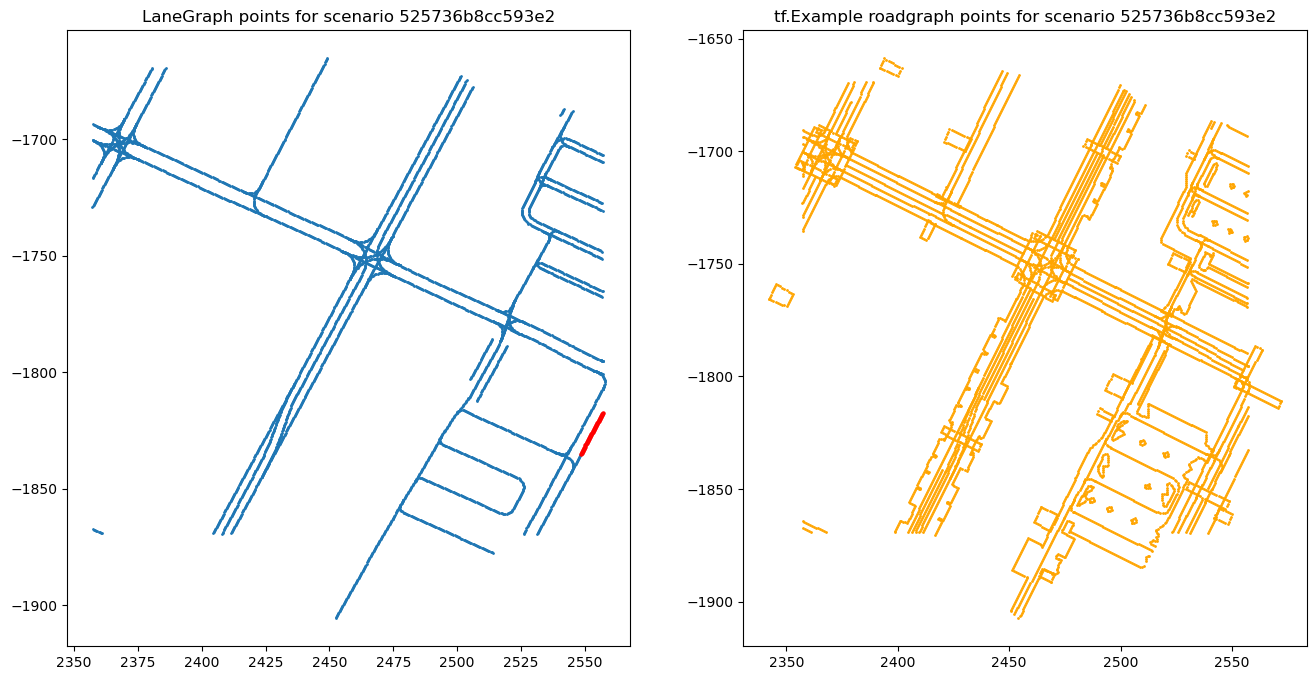

[matched] scenario_id='4a93e38317c30b5'
scenario_id: 4a93e38317c30b5
nodes_xyz: (4636, 3)
polyline_edges: (4576, 2)
successor_edges: (60, 2)
left_neighbor_edges: (72, 2)


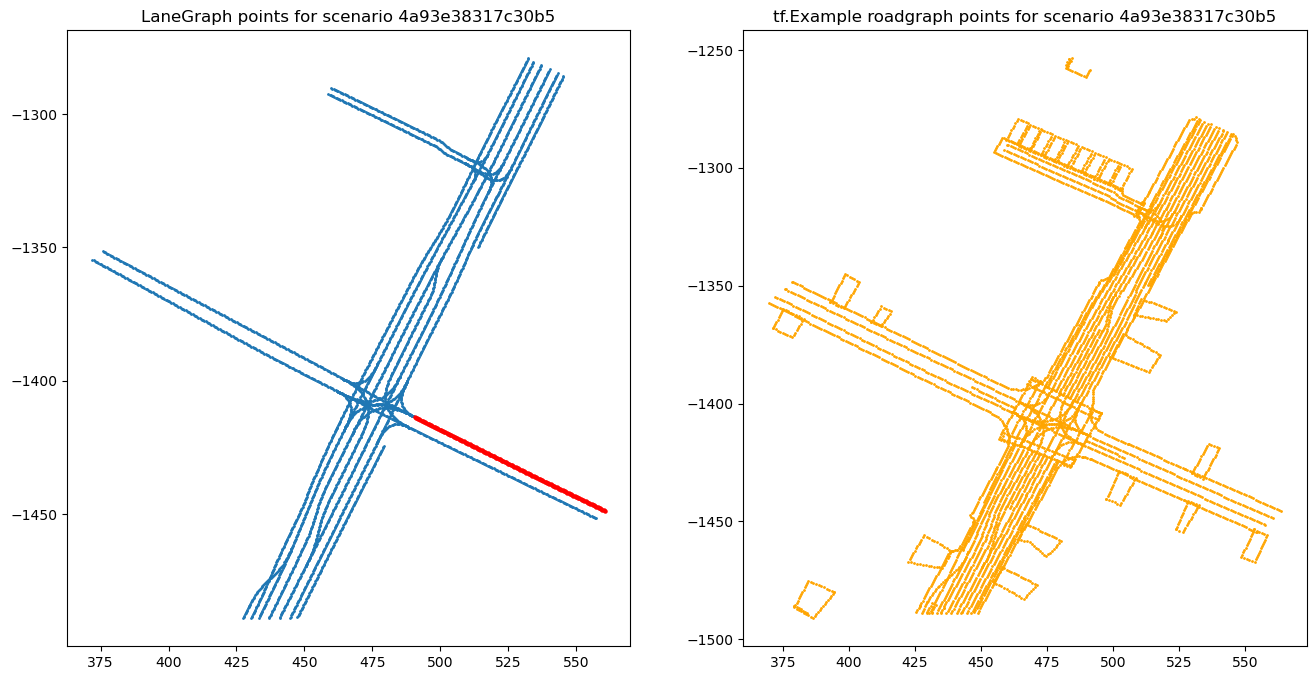

[matched] scenario_id='f6f29a30b95cdd2d'
scenario_id: f6f29a30b95cdd2d
nodes_xyz: (16836, 3)
polyline_edges: (16449, 2)
successor_edges: (420, 2)
left_neighbor_edges: (343, 2)


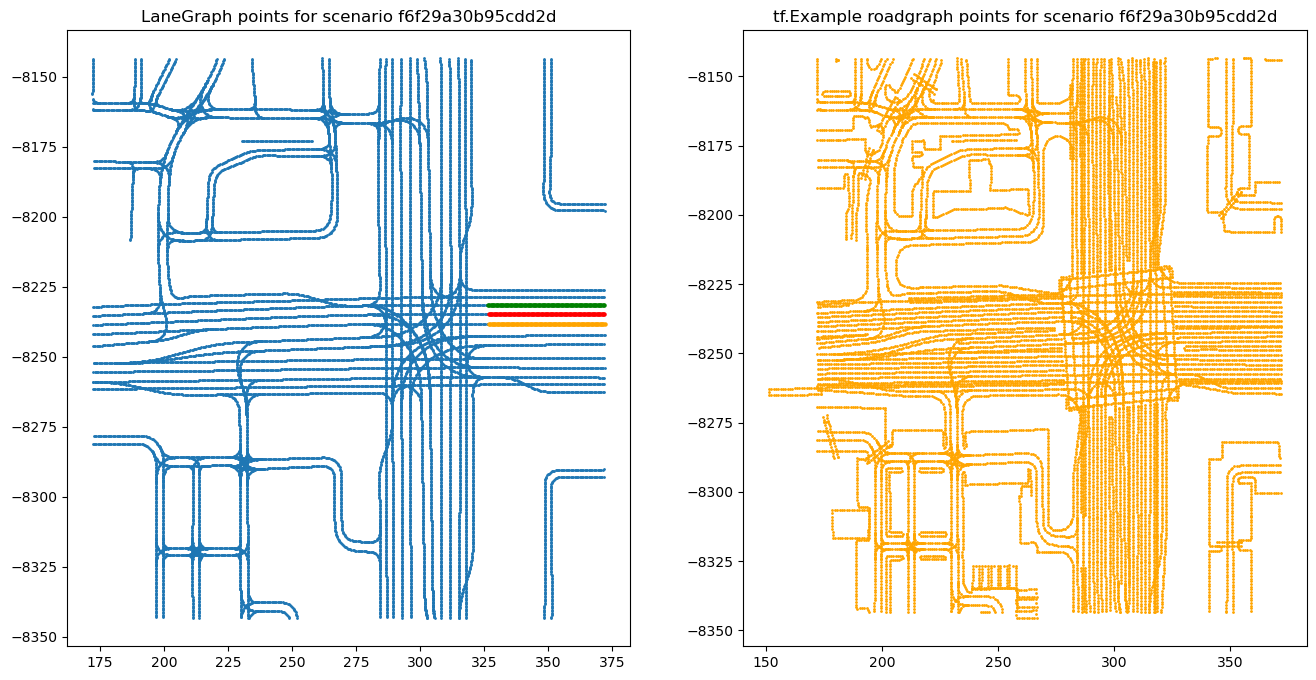

total=354, matched=3, unmatched=351


In [15]:
for scenario_id, ex, graph in iterate_tfexamples_with_lane_graph(
    tfexample_files,
    lane_graph_index,
    max_examples=3,
):
    print("=" * 80)
    print("scenario_id:", scenario_id)
    print("nodes_xyz:", graph.nodes_xyz.shape)
    print("polyline_edges:", graph.polyline_edges.shape)
    print("successor_edges:", graph.successor_edges.shape)
    print("left_neighbor_edges:", graph.left_neighbor_edges.shape)
    tfexample_pts = extract_tfexample_roadgraph_points(ex)
    tfexample_pts = tfexample_pts[tfexample_pts[:, 0] != 0]  # filter out zero points if present
    target_lane_id = graph.node_lane_ids[0]
    sampled_lane_pts = graph.nodes_xyz[graph.node_lane_ids == target_lane_id]
    target_lane_start_idx = graph.lane_id_to_node_range[target_lane_id][0]
    right_lane_start_idx = graph.right_neighbor_edges[graph.right_neighbor_edges[:, 0] == target_lane_start_idx]
    left_lane_start_idx = graph.left_neighbor_edges[graph.left_neighbor_edges[:, 0] == target_lane_start_idx]
    if len(right_lane_start_idx) > 0:
        right_lane_start_idx = right_lane_start_idx[0, 1]
        right_lane_id = graph.node_lane_ids[right_lane_start_idx]
        right_lane_start_idx, right_lane_end_idx = graph.lane_id_to_node_range[right_lane_id]
        right_lane_pts = graph.nodes_xyz[right_lane_start_idx:right_lane_end_idx]
    else:
        right_lane_pts = None
    if len(left_lane_start_idx) > 0:
        left_lane_start_idx = left_lane_start_idx[0, 1]
        left_lane_id = graph.node_lane_ids[left_lane_start_idx]
        left_lane_start_idx, left_lane_end_idx = graph.lane_id_to_node_range[left_lane_id]
        left_lane_pts = graph.nodes_xyz[left_lane_start_idx:left_lane_end_idx]
    else:
        left_lane_pts = None
    plt.figure(figsize=(16, 8))
    plt.subplot(1, 2, 1)
    plt.scatter(graph.nodes_xyz[:, 0], graph.nodes_xyz[:, 1], s=1, label="LaneGraph nodes")
    plt.scatter(sampled_lane_pts[:, 0], sampled_lane_pts[:, 1], s=5, label="LaneGraph lane points", color="red")
    if right_lane_pts is not None:
        plt.scatter(right_lane_pts[:, 0], right_lane_pts[:, 1], s=5, label="LaneGraph right neighbor lane points", color="green")
    if left_lane_pts is not None:
        plt.scatter(left_lane_pts[:, 0], left_lane_pts[:, 1], s=5, label="LaneGraph left neighbor lane points", color="orange")
    plt.title(f"LaneGraph points for scenario {scenario_id}")
    plt.subplot(1, 2, 2)
    plt.scatter(tfexample_pts[:, 0], tfexample_pts[:, 1], s=1, label="tf.Example roadgraph points", color="orange")
    plt.title(f"tf.Example roadgraph points for scenario {scenario_id}")
    plt.show()

    # 여기서 ex의 agent/state tensors와 graph를 같이 사용하면 됨

# example_main()

In [5]:
graph.left_neighbor_edges

array([[    0, 14982],
       [  145,    92],
       [  148,  9166],
       [  148,  9266],
       [  355,   248],
       [  461,  9366],
       [  503,   545],
       [  545,   461],
       [  661,   654],
       [  697,   690],
       [  791,   875],
       [  791,   830],
       [  791,  1783],
       [  791,  1826],
       [  791,  1718],
       [  830,   875],
       [  830,  1783],
       [  993,   945],
       [  993,  1011],
       [  993,   830],
       [  993,  1783],
       [ 1011,   945],
       [ 1011,   875],
       [ 1064,  1146],
       [ 1112,  1230],
       [ 1122,  1075],
       [ 1178,  1191],
       [ 1178,  1096],
       [ 1250,  1230],
       [ 1275,  1295],
       [ 1275,  1615],
       [ 1324,  1335],
       [ 1358,  1335],
       [ 1408,  1436],
       [ 1408,  8896],
       [ 1499,  1522],
       [ 1499,  1295],
       [ 1594,  1615],
       [ 1594,  1522],
       [ 1639,  1718],
       [ 1639,  1674],
       [ 1639,   875],
       [ 1674,  1718],
       [ 16

In [4]:
print(graph.successor_edges)
print(graph.polyline_edges.shape)

[[   91  4178]
 [   94   232]
 [  144  9730]
 [  144  9706]
 [  147   232]
 [  231  7787]
 [  247   355]
 [  247   248]
 [  247  9467]
 [  354  7951]
 [  460  7939]
 [  653  1396]
 [  660   668]
 [  667   668]
 [  689  1250]
 [  689  1230]
 [  705   706]
 [  829   935]
 [  874  1745]
 [  913  1763]
 [  944  1133]
 [  944  1122]
 [  992   914]
 [ 1010  1745]
 [ 1054  1763]
 [ 1063  1011]
 [ 1063   993]
 [ 1063   945]
 [ 1074  1055]
 [ 1092   760]
 [ 1095  1096]
 [ 1095  1112]
 [ 1111  1208]
 [ 1121   733]
 [ 1132   760]
 [ 1145  1093]
 [ 1165  1055]
 [ 1177  1093]
 [ 1190  1208]
 [ 1207  1263]
 [ 1229   690]
 [ 1229   697]
 [ 1249   733]
 [ 1262  1263]
 [ 1267  1064]
 [ 1267  1075]
 [ 1274  1358]
 [ 1294  1474]
 [ 1323  1576]
 [ 1334  1352]
 [ 1351  1370]
 [ 1357  1275]
 [ 1357  1295]
 [ 1369  1370]
 [ 1407  1352]
 [ 1435  9017]
 [ 1473  8957]
 [ 1498  1408]
 [ 1498  1436]
 [ 1521  1576]
 [ 1550  1268]
 [ 1575  1499]
 [ 1575  1522]
 [ 1593  1674]
 [ 1593  1718]
 [ 1593  1639]
 [ 1614  1